In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [39]:
train_df = pd.read_parquet(r"train_df_preprocessed.parquet")
test_df = pd.read_parquet(r"test_df_preprocessed.parquet")

In [28]:
classes = train_df[' Label'].value_counts().to_list()
NUM_CLASSES = len(classes)
classes

[31786, 30000, 30000, 25605, 10293, 7938, 5897, 5796, 5499, 1507, 983, 720]

In [29]:
y = train_df[' Label']

X = train_df.drop(' Label', axis=1)

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform


param_dist = {
    
    'class_weight': ['balanced'],

    # Controls complexity and speed:
    'learning_rate': loguniform(0.01, 0.2), 
    'n_estimators': [100, 150],
    'num_leaves': [20, 31, 50], 

    # Controls stability and overfitting :
    'min_child_samples': [30, 50, 80],
    'max_depth': [6, 8, 10]
}

In [32]:
import lightgbm as lgb
# Initialize the base LightGBM model (use GPU and all cores)
lgbm_base = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=NUM_CLASSES,
    device='gpu',
    n_jobs=1,
    random_state=42,
)

# Initialize Randomized Search CV
# n_iter=20 means it will try 20 different parameter combinations (faster than Grid Search)
random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=20, # Number of parameter settings that are sampled
    scoring='f1_macro', # THE CRITICAL METRIC
    cv=skf, # Use our 5-Fold Stratified K-Fold
    verbose=2,
    random_state=42,
    n_jobs=1
)

print("Starting Randomized Search CV for LightGBM tuning...")
# X and y are the full training features and encoded labels
random_search.fit(X, y)
print("Tuning complete.")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Info] 19 dense feature groups (2.38 MB) transferred to GPU in 0.003638 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[CV] END class_weight=balanced, learning_rate=0.08834921226320053, max_depth=10, min_child_samples=50, n_estimators=100, num_leaves=20; total time=  13.8s
[LightGBM] [Warning] Found whites

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
39 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/engine.py",

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4428
[LightGBM] [Info] Number of data points in the train set: 156024, number of used features: 20
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (2.98 MB) transferred to GPU in 0.007835 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start train

In [33]:
# Get the best parameters found
best_params = random_search.best_params_
print("\n=============================================")
print("🏆 Best Hyperparameters Found:")
print(best_params)

# Get the best score achieved
best_score = random_search.best_score_
print(f"\nBest Mean F1-Score (macro) from CV: {best_score:.4f}")
print("=============================================")

# Use the best model found by the search
final_tuned_lgbm = random_search.best_estimator_

# Check the score on the final hold-out test set (X_test, y_test)
# You would need to load and encode y_test here first!
# X_test_final = test_df.drop(' Label', axis=1)
# y_test_encoded = le.transform(test_df[' Label'])

# final_test_pred = final_tuned_lgbm.predict(X_test_final)
# final_f1 = f1_score(y_test_encoded, final_test_pred, average='macro', zero_division=0)
# print(f"Final Tuned F1-Score on Test Set (Friday Traffic): {final_f1:.4f}")


🏆 Best Hyperparameters Found:
{'class_weight': 'balanced', 'learning_rate': np.float64(0.023927528765580644), 'max_depth': 10, 'min_child_samples': 80, 'n_estimators': 150, 'num_leaves': 50}

Best Mean F1-Score (macro) from CV: 0.9363


In [43]:
y_test = test_df[' Label']

X_test = test_df.drop(' Label', axis=1)

Starting prediction on the hold-out test set...
✅ Predictions complete.

🏆 FINAL CLASSIFICATION REPORT (Generalization Test)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    120000
           1       0.59      0.99      0.74       983
           2       1.00      1.00      1.00    102422
           9       1.00      1.00      1.00    127144

   micro avg       1.00      1.00      1.00    350549
   macro avg       0.90      1.00      0.93    350549
weighted avg       1.00      1.00      1.00    350549

Final Macro F1-Score on Test Set: 0.3112


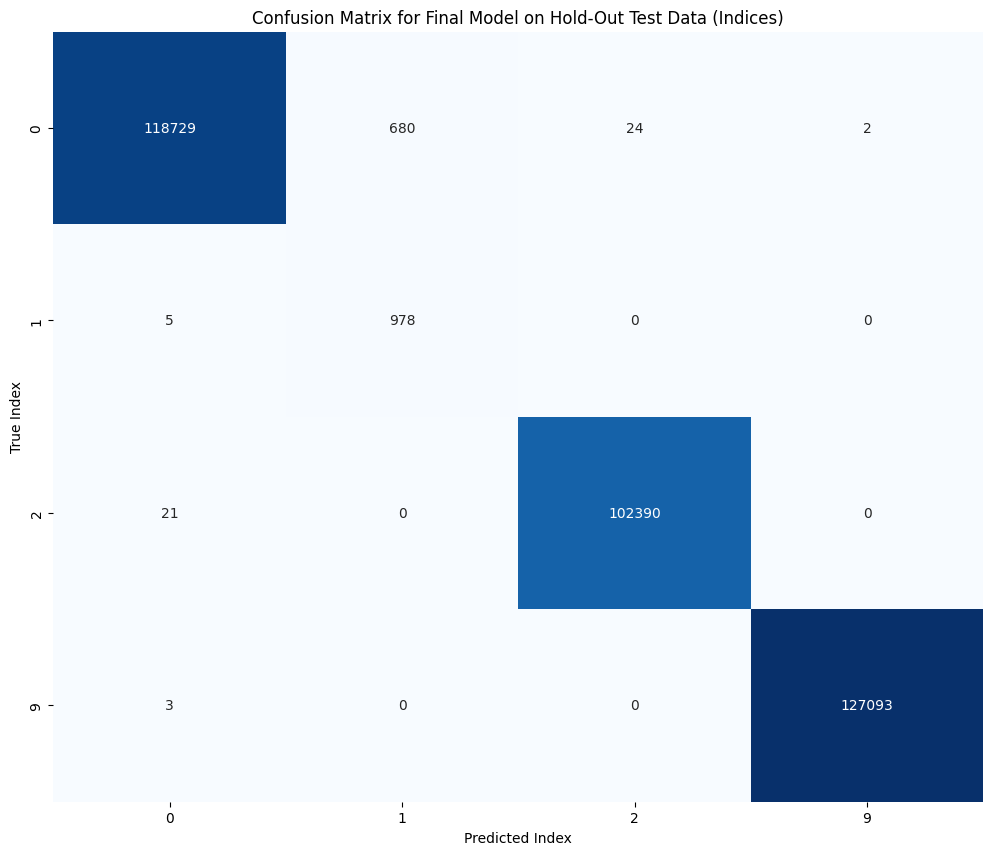

In [45]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assumptions: X_test, y_test (encoded integers), and final_tuned_lgbm are loaded ---

# 1. Make Predictions
print("Starting prediction on the hold-out test set...")
# y_pred_encoded will be a NumPy array of predicted class indices (e.g., 0, 1, 2, ...)
y_pred_encoded = final_tuned_lgbm.predict(X_test)
print("✅ Predictions complete.")

# 2. Get the Unique Class Indices
# This automatically determines the labels present in your data for the reports
labels = np.unique(y_test)

# 3. Generate Classification Report (The Final Metrics)
print("\n=======================================================")
print("🏆 FINAL CLASSIFICATION REPORT (Generalization Test)")
print("=======================================================")
# The report will use the integer indices (0, 1, 2, ...) as target names
print(classification_report(
    y_test,
    y_pred_encoded,
    labels=labels, # Use the unique labels found
    zero_division=0
))
print("=======================================================")

# 4. Report Final Macro F1 Score
final_f1_macro = f1_score(y_test, y_pred_encoded, average='macro', zero_division=0)
print(f"Final Macro F1-Score on Test Set: {final_f1_macro:.4f}")

# 5. Generate and Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred_encoded, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=labels, # Use the integer class indices on the axes
    yticklabels=labels
)
plt.title('Confusion Matrix for Final Model on Hold-Out Test Data (Indices)')
plt.xlabel('Predicted Index')
plt.ylabel('True Index')
plt.show()

Starting prediction on the hold-out test set...
✅ Predictions complete.

🏆 FINAL CLASSIFICATION REPORT (Generalization Test)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30000
           1       0.99      1.00      1.00       983
           2       1.00      1.00      1.00     25605
           3       1.00      1.00      1.00     10293
           4       1.00      1.00      1.00     30000
           5       1.00      1.00      1.00      5499
           6       1.00      1.00      1.00      5796
           7       1.00      1.00      1.00      7938
           8       0.58      0.83      0.68       720
           9       1.00      1.00      1.00     31786
          10       1.00      1.00      1.00      5897
          11       0.90      0.72      0.80      1507

    accuracy                           1.00    156024
   macro avg       0.96      0.96      0.96    156024
weighted avg       1.00      1.00      1.00    156024

Final Ma

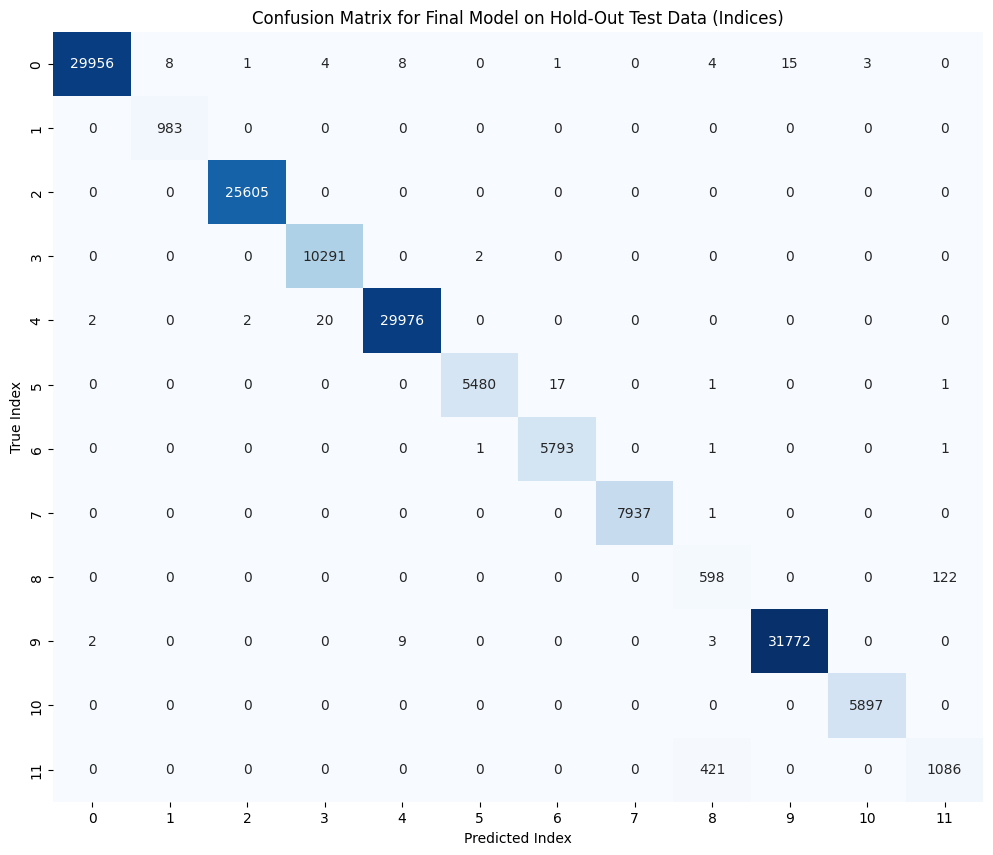

In [38]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assumptions: X_test, y_test (encoded integers), and final_tuned_lgbm are loaded ---

# 1. Make Predictions
print("Starting prediction on the hold-out test set...")
# y_pred_encoded will be a NumPy array of predicted class indices (e.g., 0, 1, 2, ...)
y_pred = final_tuned_lgbm.predict(X)
print("✅ Predictions complete.")

# 2. Get the Unique Class Indices
# This automatically determines the labels present in your data for the reports
labels = np.unique(y)

# 3. Generate Classification Report (The Final Metrics)
print("\n=======================================================")
print("🏆 FINAL CLASSIFICATION REPORT (Generalization Test)")
print("=======================================================")
# The report will use the integer indices (0, 1, 2, ...) as target names
print(classification_report(
    y,
    y_pred,
    labels=labels, # Use the unique labels found
    zero_division=0
))
print("=======================================================")

# 4. Report Final Macro F1 Score
final_f1_macro = f1_score(y, y_pred, average='macro', zero_division=0)
print(f"Final Macro F1-Score on Test Set: {final_f1_macro:.4f}")

# 5. Generate and Visualize Confusion Matrix
cm = confusion_matrix(y, y_pred, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=labels, # Use the integer class indices on the axes
    yticklabels=labels
)
plt.title('Confusion Matrix for Final Model on Hold-Out Test Data (Indices)')
plt.xlabel('Predicted Index')
plt.ylabel('True Index')
plt.show()